# Identitas Diri
Nama : Muhammad Fattahul Alim

NIM : 244107020018

Kelas : TI - 3G

Absen : 15


In [1]:
# import library & lokasi file hasil
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import warnings
from collections import Counter

from google.colab import drive
drive.mount('/content/drive')

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120

BASE = "/content/drive/MyDrive/ml-sem5/kuis1"
DIR_KMEANS = os.path.join(BASE, "outputKmeans_5050")
DIR_DBSCAN = os.path.join(BASE, "outputDBSCAN_5050")
OUTPUT_DIR = os.path.join(BASE, "outputPerbandingan_5050")
os.makedirs(OUTPUT_DIR, exist_ok=True)

FILES = [
    ('K-Means', 'Euclidean', os.path.join(DIR_KMEANS, 'evaluasi_kmeans_euclidean.xlsx')),
    ('K-Means', 'Manhattan', os.path.join(DIR_KMEANS, 'evaluasi_kmeans_manhattan.xlsx')),
    ('K-Means', 'Cosine',    os.path.join(DIR_KMEANS, 'evaluasi_kmeans_cosine.xlsx')),
    ('DBSCAN',  'Euclidean', os.path.join(DIR_DBSCAN, 'evaluasi_dbscan_euclidean.xlsx')),
    ('DBSCAN',  'Manhattan', os.path.join(DIR_DBSCAN, 'evaluasi_dbscan_manhattan.xlsx')),
    ('DBSCAN',  'Cosine',    os.path.join(DIR_DBSCAN, 'evaluasi_dbscan_cosine.xlsx')),
]

# Cek file yang sudah ada
for algo, metrik, path in FILES:
    status = "ADA" if os.path.exists(path) else "BELUM ADA"
    print(f"[{status}] {algo:8s} {metrik:10s} -> {path}")


Mounted at /content/drive
[ADA] K-Means  Euclidean  -> /content/drive/MyDrive/ml-sem5/kuis1/outputKmeans_5050/evaluasi_kmeans_euclidean.xlsx
[ADA] K-Means  Manhattan  -> /content/drive/MyDrive/ml-sem5/kuis1/outputKmeans_5050/evaluasi_kmeans_manhattan.xlsx
[ADA] K-Means  Cosine     -> /content/drive/MyDrive/ml-sem5/kuis1/outputKmeans_5050/evaluasi_kmeans_cosine.xlsx
[ADA] DBSCAN   Euclidean  -> /content/drive/MyDrive/ml-sem5/kuis1/outputDBSCAN_5050/evaluasi_dbscan_euclidean.xlsx
[ADA] DBSCAN   Manhattan  -> /content/drive/MyDrive/ml-sem5/kuis1/outputDBSCAN_5050/evaluasi_dbscan_manhattan.xlsx
[ADA] DBSCAN   Cosine     -> /content/drive/MyDrive/ml-sem5/kuis1/outputDBSCAN_5050/evaluasi_dbscan_cosine.xlsx


In [2]:
# baca & samakan kolom semua hasil
def ambil(df, awalan):
    # ambil nilai dari kolom yang namanya diawali teks tertentu (nama kolom tiap file sedikit berbeda)
    kolom = [c for c in df.columns if c.startswith(awalan)]
    return df[kolom[0]].iloc[0] if kolom else np.nan

rows = []
for algo, metrik, path in FILES:
    if not os.path.exists(path):
        print(f"[LEWAT] File belum ada: {path}")
        continue
    d = pd.read_excel(path, sheet_name='Ringkasan_Evaluasi')

    if algo == 'K-Means':
        n_klaster = ambil(d, 'Optimal k')
        parameter = f"k = {int(n_klaster)}"
        noise = np.nan
    else:
        n_klaster = ambil(d, 'Jumlah Klaster')
        parameter = f"eps = {ambil(d, 'eps')}, MinPts = {int(ambil(d, 'MinPts'))}"
        noise = ambil(d, 'Noise (%)')

    rows.append({
        'Algoritma': algo,
        'Metrik Jarak': metrik,
        'Parameter': parameter,
        'Jumlah Data': ambil(d, 'Jumlah Data'),
        'Jumlah Klaster': n_klaster,
        'Noise (%)': noise,
        'Silhouette (↑)': ambil(d, 'Silhouette'),
        'Davies–Bouldin (↓)': ambil(d, 'Davies'),
        'Calinski–Harabasz (↑)': ambil(d, 'Calinski'),
        'Waktu Eksekusi (s) (↓)': ambil(d, 'Execution Time'),
        'Iterasi (↓)': ambil(d, 'Iterations'),
        'Nilai Objektif': ambil(d, 'Objective Value'),
    })

perbandingan = pd.DataFrame(rows)
print(f"[INFO] {len(perbandingan)} dari {len(FILES)} hasil berhasil dibaca.")


[INFO] 6 dari 6 hasil berhasil dibaca.


In [3]:
# tabel perbandingan per algoritma
metrik_nilai = ['Silhouette (↑)', 'Davies–Bouldin (↓)', 'Calinski–Harabasz (↑)', 'Waktu Eksekusi (s) (↓)']

kolom_tabel = {
    'K-Means': ['Metrik Jarak', 'Parameter', 'Jumlah Data', 'Jumlah Klaster',
                'Silhouette (↑)', 'Davies–Bouldin (↓)', 'Calinski–Harabasz (↑)',
                'Waktu Eksekusi (s) (↓)', 'Iterasi (↓)', 'Nilai Objektif'],
    'DBSCAN':  ['Metrik Jarak', 'Parameter', 'Jumlah Data', 'Jumlah Klaster', 'Noise (%)',
                'Silhouette (↑)', 'Davies–Bouldin (↓)', 'Calinski–Harabasz (↑)', 'Waktu Eksekusi (s) (↓)'],
}

tabel_algo = {}
for algo in ['K-Means', 'DBSCAN']:
    sub = perbandingan[perbandingan['Algoritma'] == algo][kolom_tabel[algo]].reset_index(drop=True)
    tabel_algo[algo] = sub
    print("=" * 120)
    print(f"PERBANDINGAN METRIK JARAK - {algo.upper()}")
    print("=" * 120)
    print(sub.to_string(index=False))
    print()

excel_path = os.path.join(OUTPUT_DIR, "perbandingan_per_algoritma.xlsx")
with pd.ExcelWriter(excel_path, engine='openpyxl') as writer:
    for algo, sub in tabel_algo.items():
        sub.to_excel(writer, sheet_name=algo, index=False)
    perbandingan.to_excel(writer, sheet_name='Gabungan_Pelengkap', index=False)
print(f"[SIMPAN] Tabel perbandingan disimpan ke: '{excel_path}'")

PERBANDINGAN METRIK JARAK - K-MEANS
Metrik Jarak Parameter  Jumlah Data  Jumlah Klaster  Silhouette (↑)  Davies–Bouldin (↓)  Calinski–Harabasz (↑)  Waktu Eksekusi (s) (↓)  Iterasi (↓)  Nilai Objektif
   Euclidean     k = 4        10000               4          0.1081              2.3639                1148.52                 0.09985         20.0       111549.53
   Manhattan     k = 4        10000               4          0.1428              2.7753                 818.45                 0.05988         10.0        76309.44
      Cosine     k = 4        10000               4          0.1921              2.5023                1022.91                 0.29504         35.0         5128.19

PERBANDINGAN METRIK JARAK - DBSCAN
Metrik Jarak                          Parameter  Jumlah Data  Jumlah Klaster  Noise (%)  Silhouette (↑)  Davies–Bouldin (↓)  Calinski–Harabasz (↑)  Waktu Eksekusi (s) (↓)
   Euclidean          eps = 3.6743, MinPts = 30        10000               2       0.59          0.25

[SIMPAN] Grafik K-Means disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputPerbandingan_5050/perbandingan_kmeans.png'


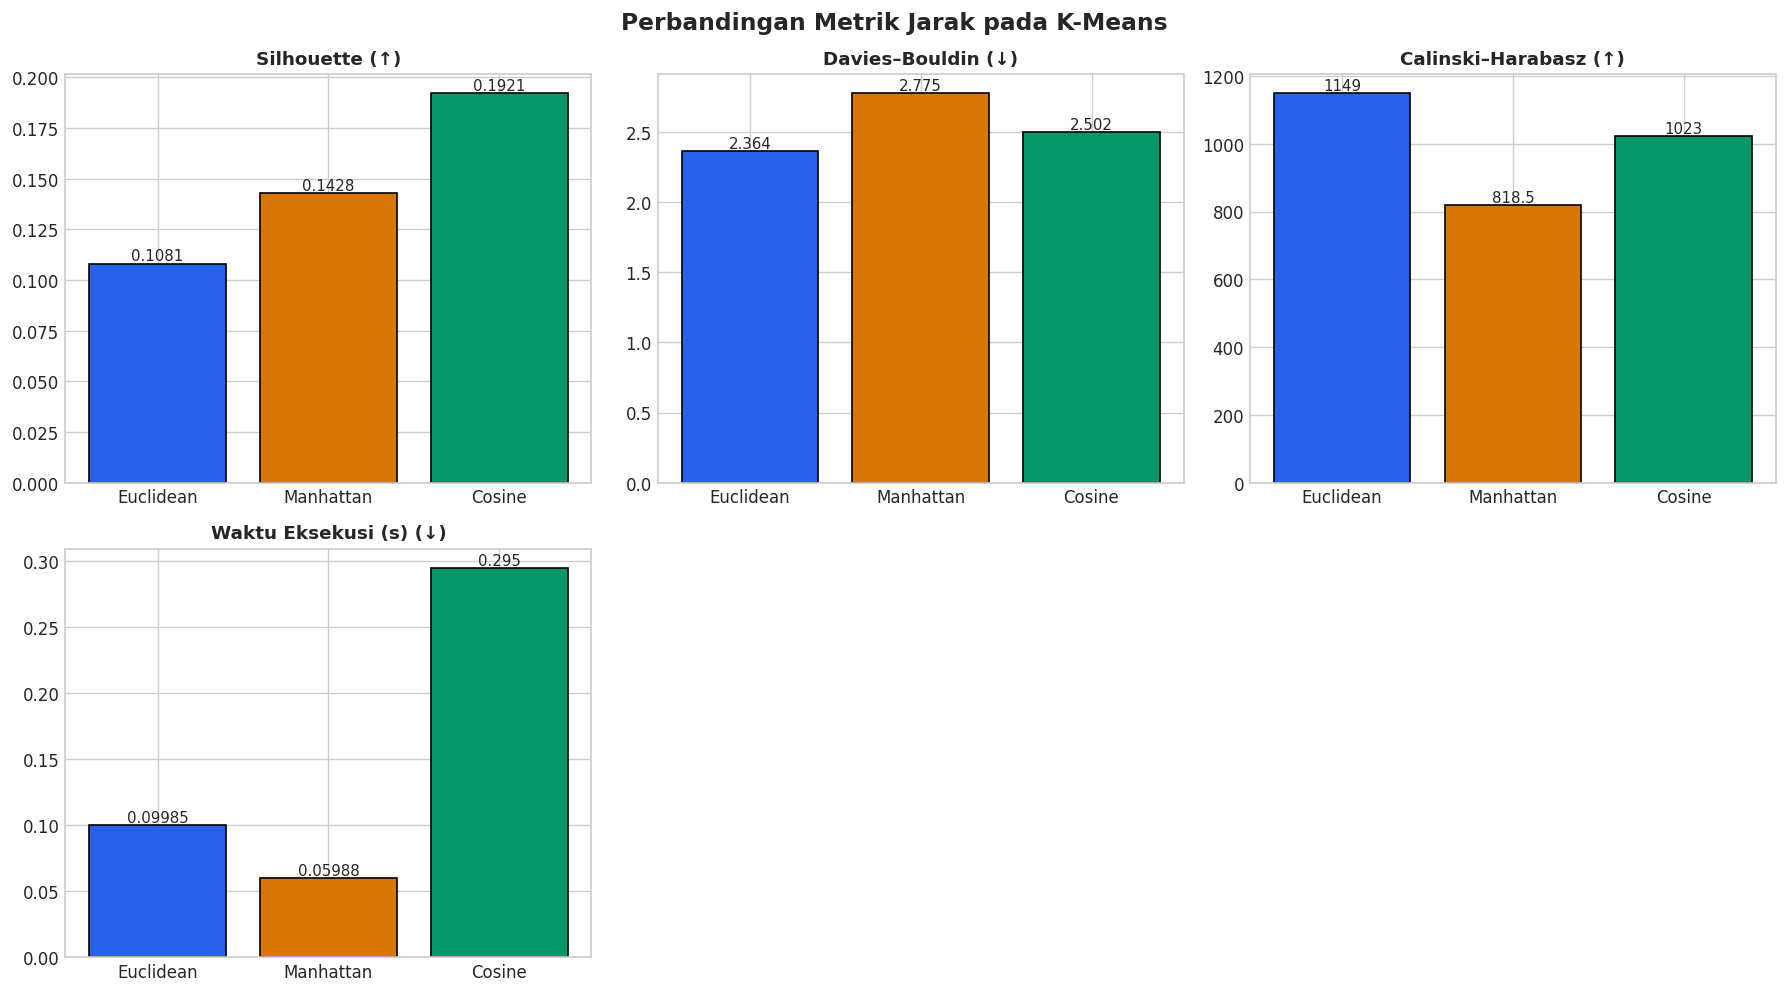

[SIMPAN] Grafik DBSCAN disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputPerbandingan_5050/perbandingan_dbscan.png'


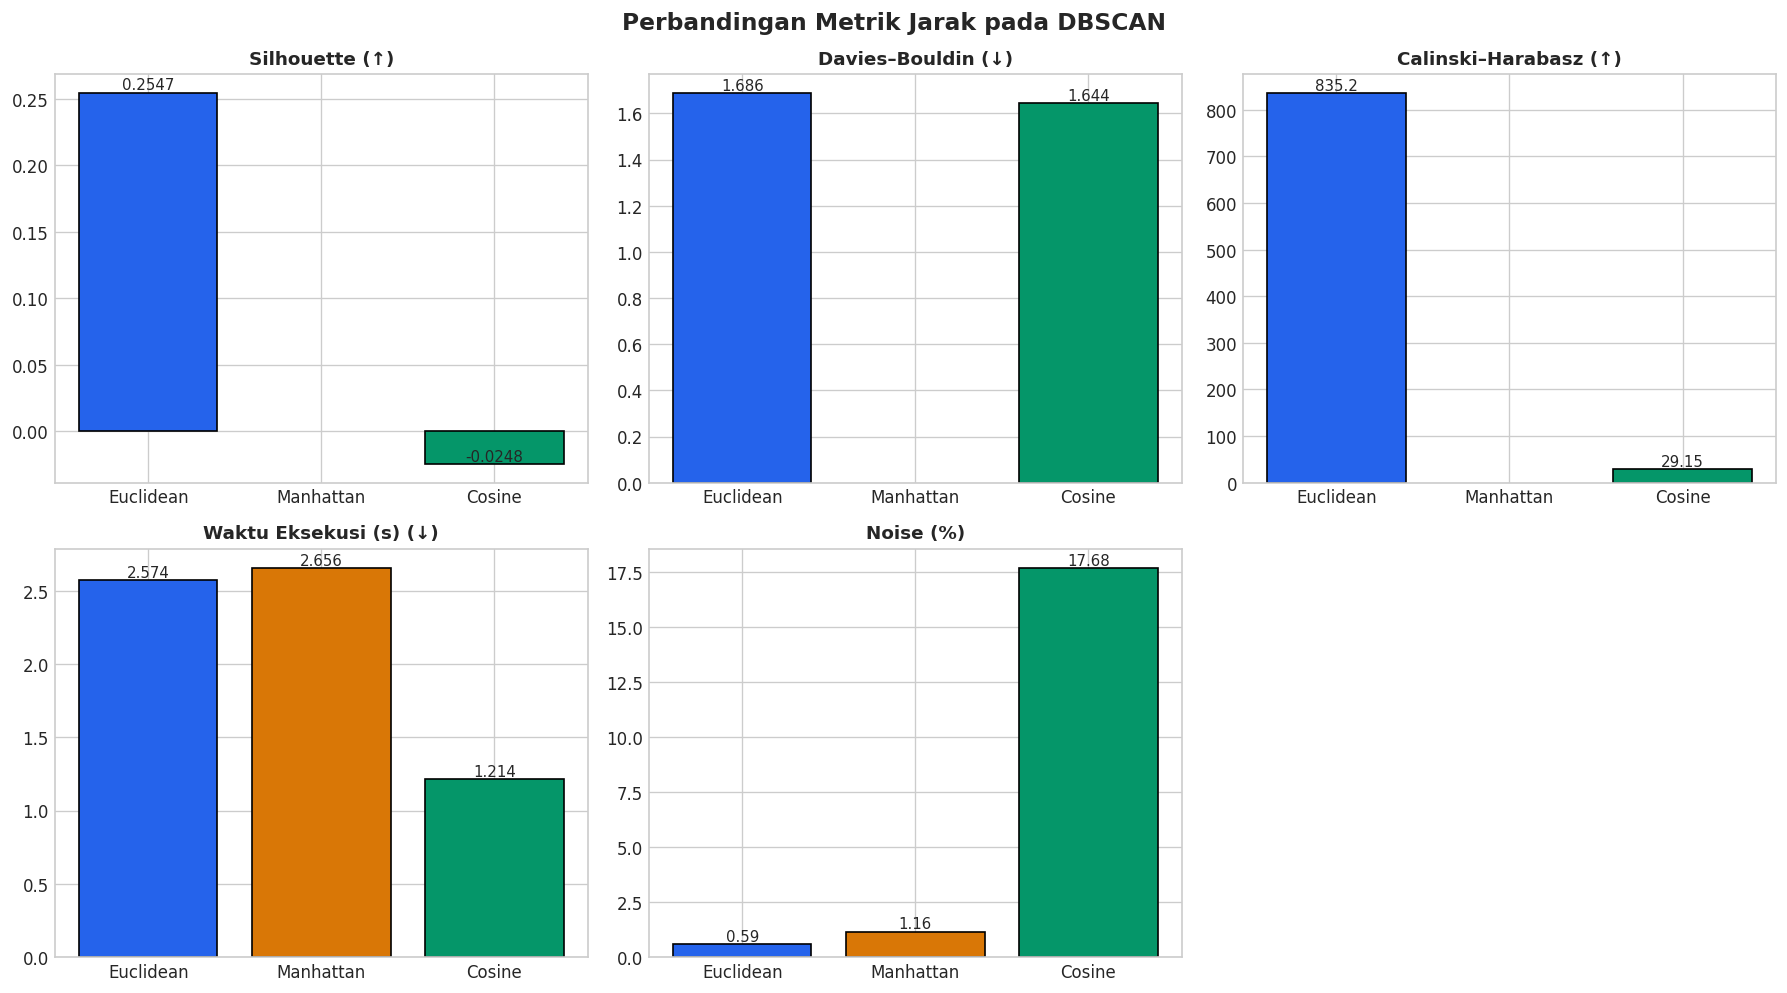

In [4]:
# grafik perbandingan per algoritma
warna_metrik = {'Euclidean': '#2563EB', 'Manhattan': '#D97706', 'Cosine': '#059669'}

def plot_algoritma(algo):
    sub = tabel_algo[algo]
    panels = [m for m in (metrik_nilai + (['Noise (%)'] if algo == 'DBSCAN' else [])) if sub[m].notna().any()]
    ncols = 3
    nrows = int(np.ceil(len(panels) / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4.2 * nrows))
    axes = np.atleast_1d(axes).ravel()

    for ax, m in zip(axes, panels):
        ax.bar(sub['Metrik Jarak'], sub[m],
               color=[warna_metrik[x] for x in sub['Metrik Jarak']], edgecolor='black')
        for i, v in enumerate(sub[m]):
            ax.text(i, v, f'{v:.4g}', ha='center', va='bottom', fontsize=9)
        ax.set_title(m, fontsize=11, fontweight='bold')
    for ax in axes[len(panels):]:
        ax.axis('off')

    plt.suptitle(f'Perbandingan Metrik Jarak pada {algo}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    path = os.path.join(OUTPUT_DIR, f"perbandingan_{algo.lower().replace('-', '')}.png")
    plt.savefig(path, dpi=300)
    print(f"[SIMPAN] Grafik {algo} disimpan ke: '{path}'")
    plt.show()

plot_algoritma('K-Means')
plot_algoritma('DBSCAN')


[SIMPAN] Galeri K-Means disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputPerbandingan_5050/galeri_pca_kmeans.png'


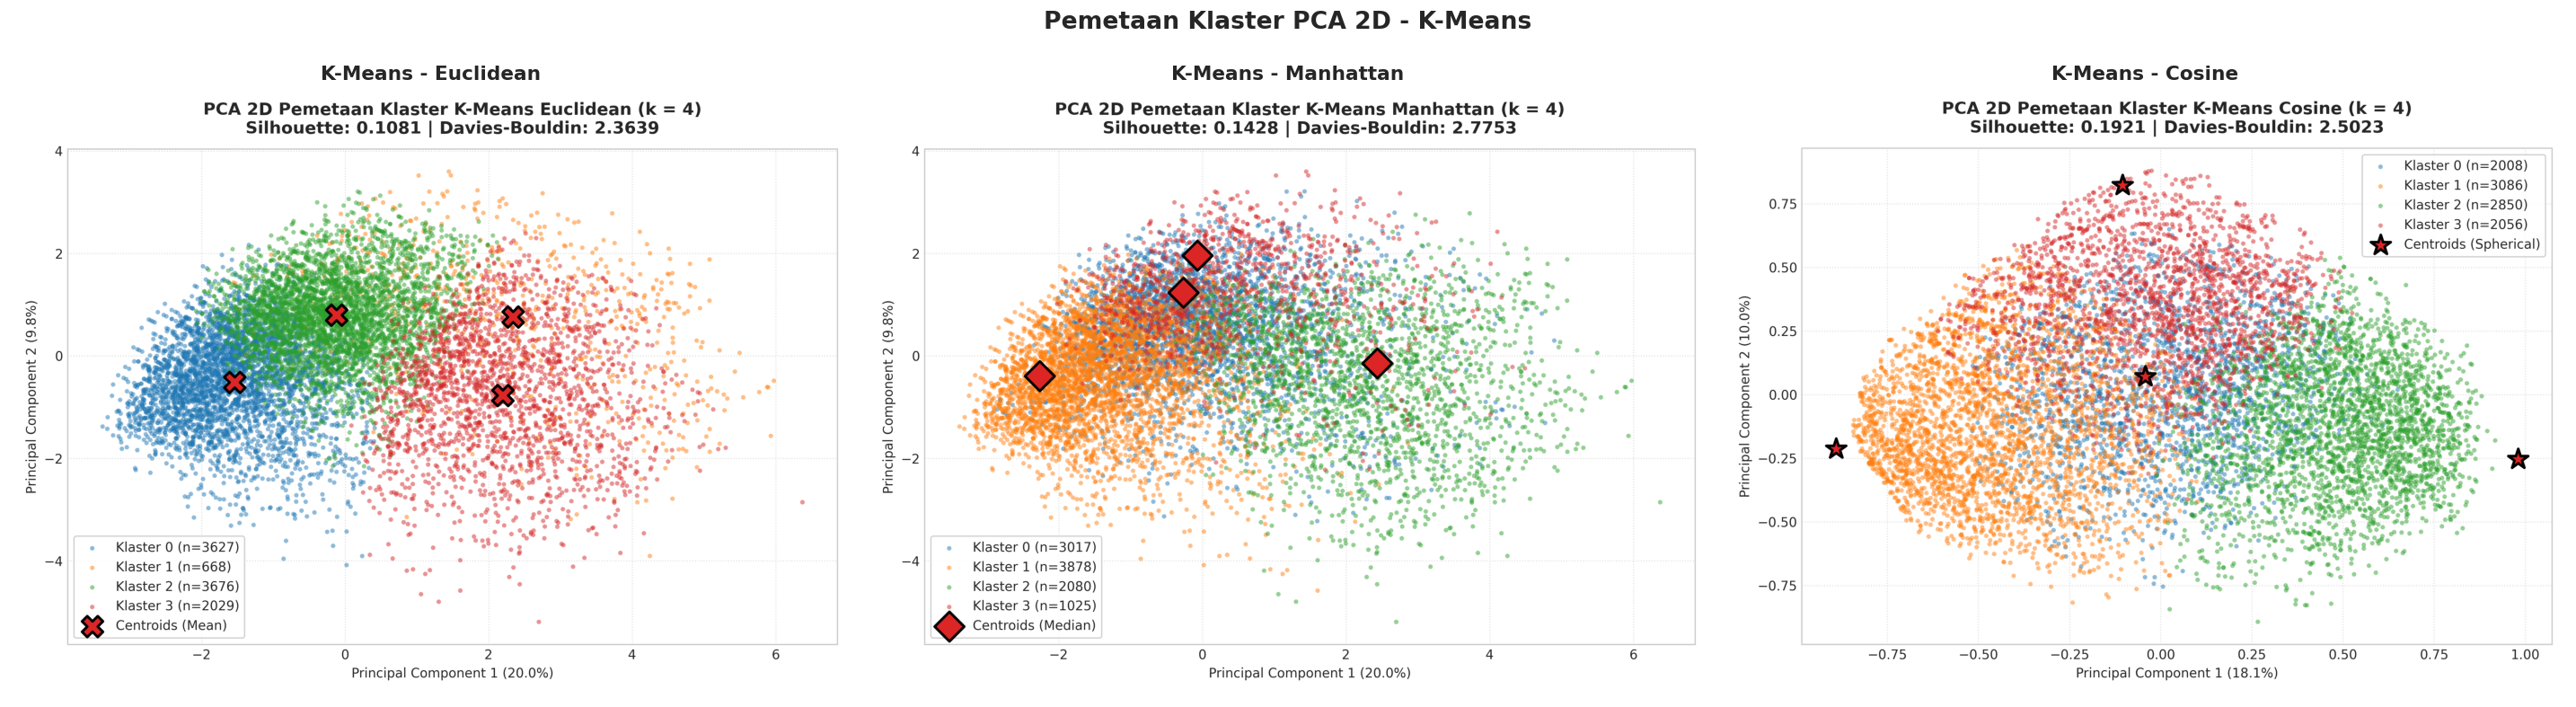

[SIMPAN] Galeri DBSCAN disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputPerbandingan_5050/galeri_pca_dbscan.png'


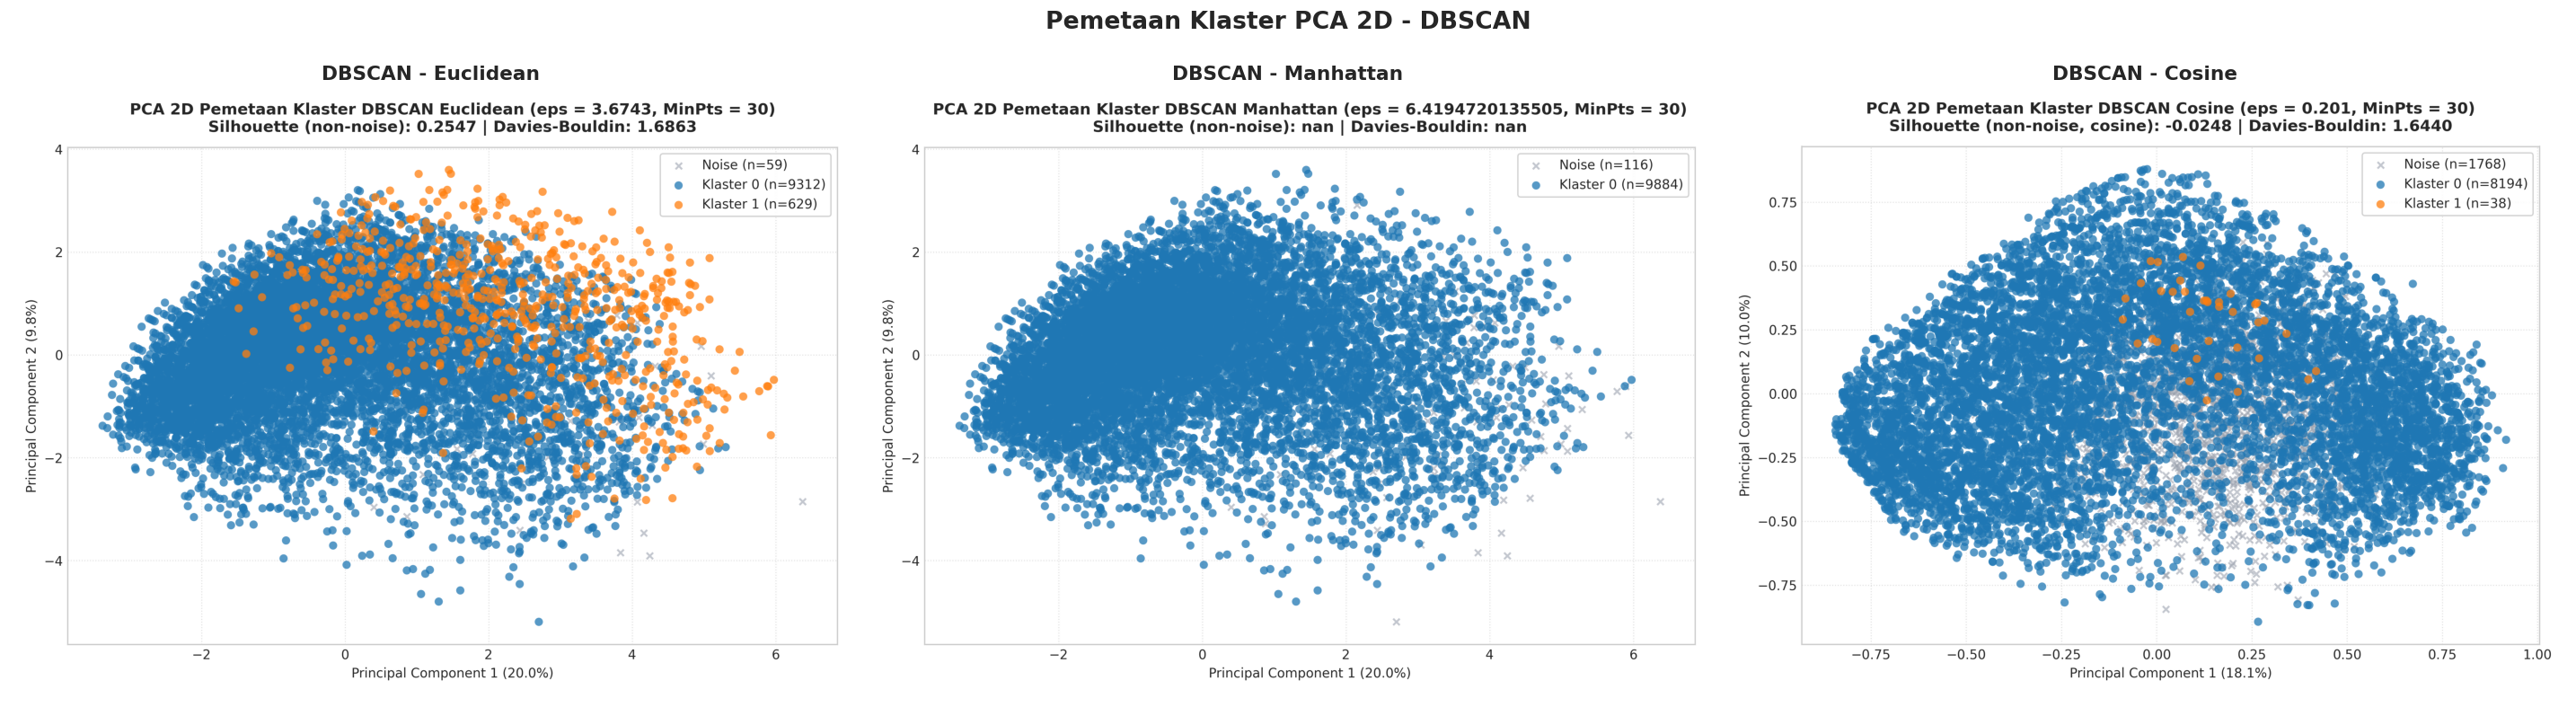

In [5]:
# galeri PCA 2D tiga metrik berdampingan (memakai gambar yang sudah tersimpan)
galeri = {
    'K-Means': [(m, os.path.join(DIR_KMEANS, f'cluster_{m.lower()}.png')) for m in ['Euclidean', 'Manhattan', 'Cosine']],
    'DBSCAN':  [(m, os.path.join(DIR_DBSCAN, f'cluster_dbscan_{m.lower()}.png')) for m in ['Euclidean', 'Manhattan', 'Cosine']],
}

for algo, items in galeri.items():
    fig, axes = plt.subplots(1, 3, figsize=(24, 7))
    for ax, (nama, path) in zip(axes, items):
        if os.path.exists(path):
            ax.imshow(mpimg.imread(path))
            ax.set_title(f'{algo} - {nama}', fontsize=13, fontweight='bold')
        else:
            ax.text(0.5, 0.5, f'Gambar belum ada:\n{os.path.basename(path)}', ha='center', va='center')
        ax.axis('off')
    plt.suptitle(f'Pemetaan Klaster PCA 2D - {algo}', fontsize=16, fontweight='bold')
    plt.tight_layout()
    galeri_path = os.path.join(OUTPUT_DIR, f"galeri_pca_{algo.lower().replace('-', '')}.png")
    plt.savefig(galeri_path, dpi=200, bbox_inches='tight')
    print(f"[SIMPAN] Galeri {algo} disimpan ke: '{galeri_path}'")
    plt.show()

In [6]:
# ringkasan pemenang & rekomendasi per algoritma
for algo in ['K-Means', 'DBSCAN']:
    sub = tabel_algo[algo]
    if len(sub) < 2:
        print(f"[LEWAT] {algo}: hasil belum lengkap.")
        continue

    juara = {
        'Silhouette': sub.loc[sub['Silhouette (↑)'].idxmax(), 'Metrik Jarak'],
        'Davies–Bouldin': sub.loc[sub['Davies–Bouldin (↓)'].idxmin(), 'Metrik Jarak'],
        'Calinski–Harabasz': sub.loc[sub['Calinski–Harabasz (↑)'].idxmax(), 'Metrik Jarak'],
        'Waktu eksekusi': sub.loc[sub['Waktu Eksekusi (s) (↓)'].idxmin(), 'Metrik Jarak'],
    }
    if algo == 'DBSCAN':
        juara['Noise paling sedikit'] = sub.loc[sub['Noise (%)'].idxmin(), 'Metrik Jarak']

    print("=" * 85)
    print(f"RINGKASAN & REKOMENDASI - {algo.upper()}")
    print("=" * 85)
    for nama, pemenang in juara.items():
        print(f"  {nama:24s}: {pemenang}")

    suara = Counter([juara['Silhouette'], juara['Davies–Bouldin'], juara['Calinski–Harabasz']])
    (top, n_top), = suara.most_common(1)
    if n_top >= 2:
        print(f"\n  Rekomendasi: {top} Distance unggul di {n_top} dari 3 metrik kualitas klaster.")
    else:
        print("\n  Tidak ada pemenang mutlak (tiap metrik kualitas dimenangkan metrik jarak berbeda); "
              "pertimbangkan Silhouette dan karakteristik data.")
    print()

RINGKASAN & REKOMENDASI - K-MEANS
  Silhouette              : Cosine
  Davies–Bouldin          : Euclidean
  Calinski–Harabasz       : Euclidean
  Waktu eksekusi          : Manhattan

  Rekomendasi: Euclidean Distance unggul di 2 dari 3 metrik kualitas klaster.

RINGKASAN & REKOMENDASI - DBSCAN
  Silhouette              : Euclidean
  Davies–Bouldin          : Cosine
  Calinski–Harabasz       : Euclidean
  Waktu eksekusi          : Cosine
  Noise paling sedikit    : Euclidean

  Rekomendasi: Euclidean Distance unggul di 2 dari 3 metrik kualitas klaster.



[SIMPAN] Grafik elbow gabungan disimpan ke: '/content/drive/MyDrive/ml-sem5/kuis1/outputPerbandingan_5050/elbow_gabungan.png'


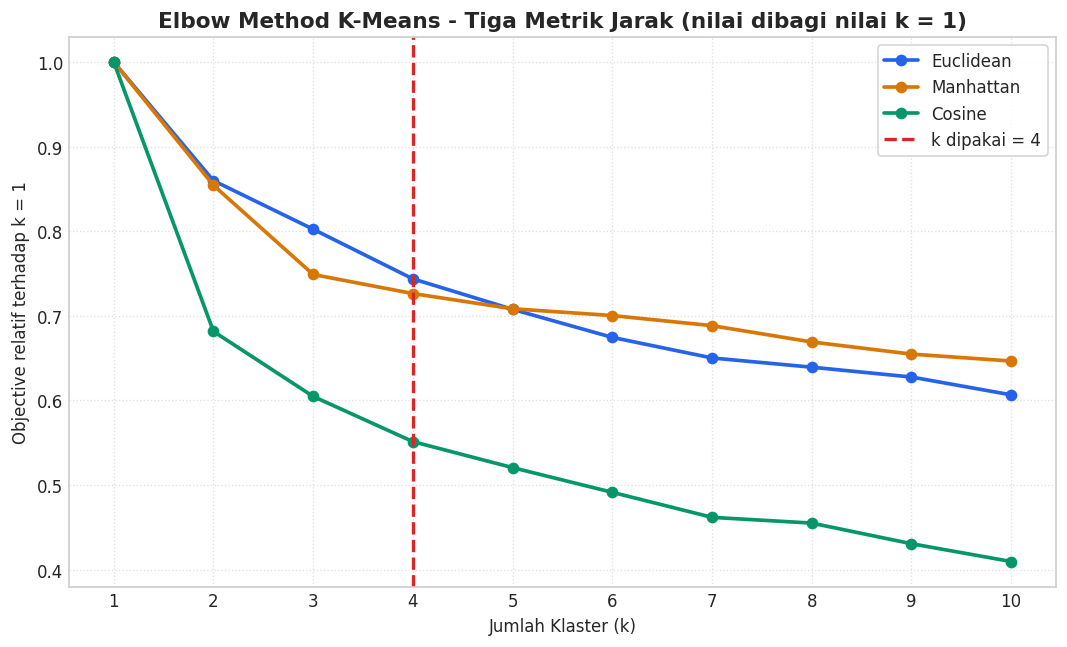

In [7]:
# grafik elbow tiga metrik dalam satu gambar (dinormalisasi agar sebanding)
warna = {'Euclidean': '#2563EB', 'Manhattan': '#D97706', 'Cosine': '#059669'}
plt.figure(figsize=(9, 5.5))
for m in ['Euclidean', 'Manhattan', 'Cosine']:
    ev = pd.read_csv(os.path.join(DIR_KMEANS, f'elbow_values_{m.lower()}.csv'))
    plt.plot(ev['k'], ev['objective'] / ev['objective'].iloc[0], marker='o', linewidth=2.2, color=warna[m], label=m)

k_pakai = int(perbandingan[(perbandingan['Algoritma'] == 'K-Means')]['Jumlah Klaster'].iloc[0])
plt.axvline(k_pakai, color='#DC2626', linestyle='--', linewidth=2, label=f'k dipakai = {k_pakai}')
plt.title('Elbow Method K-Means - Tiga Metrik Jarak (nilai dibagi nilai k = 1)', fontsize=13, fontweight='bold')
plt.xlabel('Jumlah Klaster (k)')
plt.ylabel('Objective relatif terhadap k = 1')
plt.xticks(range(1, 11))
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(frameon=True, facecolor='white')
plt.tight_layout()
elbow_gab_path = os.path.join(OUTPUT_DIR, "elbow_gabungan.png")
plt.savefig(elbow_gab_path, dpi=300)
print(f"[SIMPAN] Grafik elbow gabungan disimpan ke: '{elbow_gab_path}'")
plt.show()

In [8]:
# tabel sensitivitas k gabungan (k-1, k, k+1 untuk tiga metrik)
sens_list = []
for m in ['Euclidean', 'Manhattan', 'Cosine']:
    p = os.path.join(DIR_KMEANS, f'sensitivitas_k_{m.lower()}.csv')
    if os.path.exists(p):
        sens_list.append(pd.read_csv(p))
    else:
        print(f"[LEWAT] Belum ada: {p} (jalankan cell 11 di notebook K-Means {m})")

sens_all = pd.concat(sens_list, ignore_index=True)
sens_all['Keterangan'] = sens_all['Keterangan'].fillna('')
print("=" * 120)
print("TABEL SENSITIVITAS K - K-MEANS (semua metrik)")
print("=" * 120)
print(sens_all.to_string(index=False))

# ringkasan: satu tabel per ukuran kualitas, baris = k, kolom = metrik jarak
for kol in ['Silhouette (↑)', 'Davies–Bouldin (↓)', 'Calinski–Harabasz (↑)']:
    print(f"\n{kol}")
    print(sens_all.pivot(index='k', columns='Distance Metric', values=kol).to_string())

sens_xlsx = os.path.join(OUTPUT_DIR, "sensitivitas_k_gabungan.xlsx")
with pd.ExcelWriter(sens_xlsx, engine='openpyxl') as writer:
    sens_all.to_excel(writer, sheet_name='Semua', index=False)
    for kol, nama in [('Silhouette (↑)', 'Silhouette'), ('Davies–Bouldin (↓)', 'DaviesBouldin'), ('Calinski–Harabasz (↑)', 'CalinskiHarabasz')]:
        sens_all.pivot(index='k', columns='Distance Metric', values=kol).to_excel(writer, sheet_name=nama)
print(f"\n[SIMPAN] Tabel sensitivitas gabungan disimpan ke: '{sens_xlsx}'")

TABEL SENSITIVITAS K - K-MEANS (semua metrik)
Distance Metric  k                                       Keterangan  Silhouette (↑)  Davies–Bouldin (↓)  Calinski–Harabasz (↑)  Klaster Terkecil (%)  Klaster Terbesar (%)  Iterasi (↓)
      Euclidean  3                                                           0.1753              2.1933                1231.59                  6.68                 64.92           25
      Euclidean  4 k dipakai (acuan Euclidean) + k elbow metrik ini          0.1081              2.3639                1148.52                  6.68                 36.76           20
      Euclidean  5                                                           0.1126              2.2416                1032.53                  6.68                 34.69           36
      Manhattan  3                               k elbow metrik ini          0.1491              2.8348                1041.18                 22.35                 41.79            4
      Manhattan  4                

# Kesimpulan Kmeans
Pada K-Means, ketiga metrik jarak menghasilkan kulaitas klaster yang sama sama rendah. Metrik cosine memeroleh silhouette tertinggi 0.1513 dan callinski-harabasaz atau ch 17.993,03 dengan k = 3, diikuri oleh manhattan dengan silhouette 0,1299 dan euclidean dengan silhoutte 0,0811 di k = 4. Sebaliknya pada davies-bouldin indes euclidean memperoleh index terbaik yaitu 2,6378, sedangkan manhattan paling efisien dengan waktu eksekusi 0,72 detik. Cosine unggul pada dua dari tiga metrik kualitas klaster, namun selsihnya tidak berbeda jauh dan memerlukan 29 iterasi hingga konergen, jauh lebih banyak dibandingkan manhattan yang hanya melakukan 4 iterasi. Seluruh nilai silhouette berada di bawah 0.25, yang menunjukkan klaster pada data belum terbentuk secara tegas. Dengan demikian tidak ada metrik yang unggul secara mutlak. Cosine bisa dipilih bila memrioritaskan silhoutte dan calinski-harabasz, sementara euclidean bisa dipilih bila ingin memprioritaskan davies-bouldin, dan manhattan bisa dipilih apabila mengutamakan efisiensi komputasi


# Kesimpulan DBSCAN

Pada DBSCAN digunakan sample 10.000 data dengan minPTS = 40. Metrik euclidean memperoleh silhouette 0,2296 dan calinski-harabasz tertinggi yaitu 546,85 dan noise terendah 2,17% pada 3 klaster. Metrik Manhattan memperoleh Davies-Bouldin Index terbaik yaitu 1,1948 namun hanya membentuk 2 klaster dengan noise 27,79% sehingga hampir sepertiga data dikeluarkan dari evaluasi. Metrik Cosine memiliki kualitas terendah silhouette = 0,0920 dan davies-bouldin 2,4929 meeskipun waktu eksekusinya tercepat yaitu 1,95 detik. Namun keunggulan euclidean perlu diperhatikan lebih detail karena nilai eps yang relatif besar (4,6127) membuat noise sangat kecil, tetapi ini justru menyebabkan mayoritas data mennumpuk hanya pada satu klaster, akibatnya hasil pengelompokan jadi kurang bermakna karena gagal memperlihatkan perbedaan karakteristik antar kelompok. Sebaliknya, keunggulan davies-boudin pada manhattan sebagian disebabkan oleh banyaknya titik yang dibuang sebagai noise sehingga metrik ini dihitung pada data yang lebih mudah dipisahkan

# Kesimpulan Umum
Secara keseluruhan, karakteristik data BRFSS yang didominasi fitur biner dan ordinal dengan dimensi 20 membuat kelompok data tidak terpisah tegas, sehingga nilai evaluasi pada kedua algoritma tergolong rendah. Perbandingan lintas algoritma tidak dapat dilakukan secara langsung karena K-Means menggunakan seluruh 208.858 data, sedangkan DBSCAN menggunakan sampel 10.000 data dan mengevaluasi titik non-noise saja. Nilai Silhouette DBSCAN yang lebih tinggi daripada K-Means bukan berarti DBSCAN lebih baik, karena sebagian dipengaruhi jumlah klaster yang sedikit dan pengecualian titik noise.

In [ ]:
from google.colab import userdata
# Ambil GitHub Token
token = userdata.get('GITHUB_TOKEN')

# Clone repository
%cd /content
!git clone https://{token}@github.com/FattahulAlim/Machine_Learning_Sem5.git

# Masuk repository
%cd /content/Machine_Learning_Sem5

# Copy seluruh isi folder kuis1, termasuk semua subfolder
!cp -r "/content/drive/MyDrive/ml-sem5/kuis1/." kuis1/

# Konfigurasi Git
!git config user.email "fathalim1512@gmail.com"
!git config user.name "FattahulAlim"

# Cek perubahan
!git status

In [ ]:
# Pastikan berada di folder repository
%cd /content/Machine_Learning_Sem5

# Tambahkan semua file baru ke staging area
!git add .

# Cek kembali statusnya (sekarang akan muncul "new file: ...")
!git status

In [ ]:
# Simpan perubahan
!git commit -m "Menambahkan seluruh file kuis dan dataset Kuis 1"

# Unggah ke GitHub
!git push origin main

In [ ]:
# 1. Pastikan Anda berada di folder repository
%cd /content/Machine_Learning_Sem5

# 2. Copy kembali file yang baru saja Anda edit dari Google Drive ke folder repository
# (Perintah ini akan menimpa file lama di repo lokal Colab dengan file baru dari Drive)
!cp -r "/content/drive/MyDrive/ml-sem5/kuis1/." kuis1/

# 3. Tambahkan perubahan tersebut ke Git
!git add .

# 4. Simpan perubahan dengan pesan commit baru
!git commit -m "Revisi: Menambahkan identitas pada file notebook"

# 5. Unggah pembaruan ke GitHub
!git push origin main